In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
df = pd.read_parquet("../data/processed/tweets_ai_sentiment_hf.parquet")

df.head(10)

,id,conversation_id,created_at,date,time,timezone,tweet,language,urls,photos,...,video,thumbnail,dominios_url,tipo_fuente_url,tweet_clean,tweet_clean_filt,num_palabras_filt,tweet_hf,sentiment_label_hf,sentiment_score_hf
0,826580756675694720,826580756675694720,2017-01-31 18:59:44,2017-01-31,18:59:44,-400,What topic could spark human dialogue on AI? Artificial Intelligence Glossary for Marketers https://t.co/SPyvplngtg @hubspot @Megan_Conley_,en,[https://blog.hubspot.com/marketing/artificial-intelligence-glossary-marketers],[],...,0,None,[blog.hubspot.com],[news],what topic could spark human dialogue on ai artificial intelligence glossary for marketers,what topic could spark human dialogue on ai artificial intelligence glossary for marketers,13,What topic could spark human dialogue on AI? Artificial Intelligence Glossary for Marketers http @user @user,neutral,0.722622
1,826580719921152000,826580719921152000,2017-01-31 18:59:35,2017-01-31,18:59:35,-400,"I think #ArtificialIntelligence will augment humanity, way before it displaces it. #AI #ChasmWaxing https://t.co/SAsmyqEe2b",en,[http://bit.ly/2bWb1ly],[],...,0,None,[bit.ly],[other],i think artificialintelligence will augment humanity way before it displaces it ai chasmwaxing,i think will augment humanity way before it displaces it,10,"I think #ArtificialIntelligence will augment humanity, way before it displaces it. #AI #ChasmWaxing http",positive,0.562817
2,826580631366700928,826580631366700928,2017-01-31 18:59:14,2017-01-31,18:59:14,-400,What Managers Need to Know About Artificial Intelligence https://t.co/t6VjDcGONz via @mitsmr,en,[http://mitsmr.com/2klQ17D],[],...,0,None,[mitsmr.com],[news],what managers need to know about artificial intelligence via,what managers need to know about artificial intelligence via,9,What Managers Need to Know About Artificial Intelligence http via @user,neutral,0.845438
3,826580578954780672,826580578954780672,2017-01-31 18:59:01,2017-01-31,18:59:01,-400,4 ways Artificial Intelligence changes the game for SEO https://t.co/uJnUtUSa2E #thenextweb,en,[http://bit.ly/2koUCIB],[],...,0,None,[bit.ly],[other],4 ways artificial intelligence changes the game for seo thenextweb,4 ways artificial intelligence changes the game for seo,9,4 ways Artificial Intelligence changes the game for SEO http #thenextweb,neutral,0.593140
4,826580577457287040,826580577457287040,2017-01-31 18:59:01,2017-01-31,18:59:01,-400,Artificial Intelligence can Shape the Future of Society https://t.co/LOPLuWPt8W | follow @whyfuture_AI,en,[https://www.youtube.com/watch?v=NQefTsrSjJY],[],...,0,None,[youtube.com],[social],artificial intelligence can shape the future of society follow,artificial intelligence can shape the future of society follow,9,Artificial Intelligence can Shape the Future of Society http | follow @user,positive,0.610682
5,826580175248699520,826580175248699520,2017-01-31 18:57:25,2017-01-31,18:57:25,-400,IBM #Watson uses artificial intelligence to create rum that tastes like a holiday https://t.co/XtxV3aYADa https://t.co/Lg8Lc0KOGX,en,[http://bit.ly/2kO88U7],[https://pbs.twimg.com/media/C3iaSR9UEAAEDW5.jpg],...,1,https://pbs.twimg.com/media/C3iaSR9UEAAEDW5.jpg,[bit.ly],[other],ibm watson uses artificial intelligence to create rum that tastes like a holiday,ibm uses artificial intelligence to create rum that tastes like a holiday,12,IBM #Watson uses artificial intelligence to create rum that tastes like a holiday http http,positive,0.567571
6,826580141543415808,826580141543415808,2017-01-31 18:57:17,2017-01-31,18:57:17,-400,How Artificial Intelligence Will Revolutionize eDiscovery https://t.co/elT5C0xm0N https://t.co/OvoqxjkvgK,en,[http://upflow.co/l/45Ug],[https://pbs.twimg.com/media/C3iaQfkWQAAqKDv.jpg],...,1,https://pbs.twimg.com/media/C3iaQfkWQAAqKDv.jpg,[upflow.co],[other],how artificial intelligence will revolutionize ediscovery,how artificial intelligence will revolutionize ediscovery,6,How Artificial Intelligence Will Revolutionize eDiscovery http http,neutral,0

In [2]:
df = df[df["language"] == "en"].copy()

In [3]:
df.groupby("sentiment_label_hf")["sentiment_score_hf"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment_label_hf,,,,,,,,
negative,58725.0,0.696982,0.145917,0.335874,0.575395,0.704903,0.822889,0.965639
neutral,570890.0,0.683280,0.123213,0.334364,0.581449,0.683688,0.783654,0.956099
positive,190677.0,0.618605,0.111528,0.336274,0.529428,0.595477,0.688237,0.950370


In [4]:
df["sentiment_extreme"] = (
    (df["sentiment_label_hf"] != "neutral") &
    (df["sentiment_score_hf"] > 0.9)
)
df.head(10)

,id,conversation_id,created_at,date,time,timezone,tweet,language,urls,photos,...,thumbnail,dominios_url,tipo_fuente_url,tweet_clean,tweet_clean_filt,num_palabras_filt,tweet_hf,sentiment_label_hf,sentiment_score_hf,sentiment_extreme
0,826580756675694720,826580756675694720,2017-01-31 18:59:44,2017-01-31,18:59:44,-400,What topic could spark human dialogue on AI? Artificial Intelligence Glossary for Marketers https://t.co/SPyvplngtg @hubspot @Megan_Conley_,en,[https://blog.hubspot.com/marketing/artificial-intelligence-glossary-marketers],[],...,None,[blog.hubspot.com],[news],what topic could spark human dialogue on ai artificial intelligence glossary for marketers,what topic could spark human dialogue on ai artificial intelligence glossary for marketers,13,What topic could spark human dialogue on AI? Artificial Intelligence Glossary for Marketers http @user @user,neutral,0.722622,False
1,826580719921152000,826580719921152000,2017-01-31 18:59:35,2017-01-31,18:59:35,-400,"I think #ArtificialIntelligence will augment humanity, way before it displaces it. #AI #ChasmWaxing https://t.co/SAsmyqEe2b",en,[http://bit.ly/2bWb1ly],[],...,None,[bit.ly],[other],i think artificialintelligence will augment humanity way before it displaces it ai chasmwaxing,i think will augment humanity way before it displaces it,10,"I think #ArtificialIntelligence will augment humanity, way before it displaces it. #AI #ChasmWaxing http",positive,0.562817,False
2,826580631366700928,826580631366700928,2017-01-31 18:59:14,2017-01-31,18:59:14,-400,What Managers Need to Know About Artificial Intelligence https://t.co/t6VjDcGONz via @mitsmr,en,[http://mitsmr.com/2klQ17D],[],...,None,[mitsmr.com],[news],what managers need to know about artificial intelligence via,what managers need to know about artificial intelligence via,9,What Managers Need to Know About Artificial Intelligence http via @user,neutral,0.845438,False
3,826580578954780672,826580578954780672,2017-01-31 18:59:01,2017-01-31,18:59:01,-400,4 ways Artificial Intelligence changes the game for SEO https://t.co/uJnUtUSa2E #thenextweb,en,[http://bit.ly/2koUCIB],[],...,None,[bit.ly],[other],4 ways artificial intelligence changes the game for seo thenextweb,4 ways artificial intelligence changes the game for seo,9,4 ways Artificial Intelligence changes the game for SEO http #thenextweb,neutral,0.593140,False
4,826580577457287040,826580577457287040,2017-01-31 18:59:01,2017-01-31,18:59:01,-400,Artificial Intelligence can Shape the Future of Society https://t.co/LOPLuWPt8W | follow @whyfuture_AI,en,[https://www.youtube.com/watch?v=NQefTsrSjJY],[],...,None,[youtube.com],[social],artificial intelligence can shape the future of society follow,artificial intelligence can shape the future of society follow,9,Artificial Intelligence can Shape the Future of Society http | follow @user,positive,0.610682,False
5,826580175248699520,826580175248699520,2017-01-31 18:57:25,2017-01-31,18:57:25,-400,IBM #Watson uses artificial intelligence to create rum that tastes like a holiday https://t.co/XtxV3aYADa https://t.co/Lg8Lc0KOGX,en,[http://bit.ly/2kO88U7],[https://pbs.twimg.com/media/C3iaSR9UEAAEDW5.jpg],...,https://pbs.twimg.com/media/C3iaSR9UEAAEDW5.jpg,[bit.ly],[other],ibm watson uses artificial intelligence to create rum that tastes like a holiday,ibm uses artificial intelligence to create rum that tastes like a holiday,12,IBM #Watson uses artificial intelligence to create rum that tastes like a holiday http http,positive,0.567571,False
6,826580141543415808,826580141543415808,2017-01-31 18:57:17,2017-01-31,18:57:17,-400,How Artificial Intelligence Will Revolutionize eDiscovery https://t.co/elT5C0xm0N https://t.co/OvoqxjkvgK,en,[http://upflow.co/l/45Ug],[https://pbs.twimg.com/media/C3iaQfkWQAAqKDv.jpg],...,https://pbs.twimg.com/media/C3iaQfkWQAAqKDv.jpg,[upflow.co],[other],how artificial intelligence will revolutionize ediscovery,how artificial intelligence will revolutionize ediscovery,6,How Artificial Intelligence Will Revolution

In [5]:
df.groupby(df["created_at"].dt.year)["sentiment_label_hf"].value_counts(normalize=True)


created_at  sentiment_label_hf
2017        neutral               0.730501
            positive              0.199983
            negative              0.069516
2018        neutral               0.681741
            positive              0.251151
            negative              0.067108
2019        neutral               0.668977
            positive              0.255500
            negative              0.075523
2020        neutral               0.683594
            positive              0.241312
            negative              0.075094
2021        neutral               0.664962
            positive              0.246089
            negative              0.088948
Name: proportion, dtype: float64

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm import tqdm
tqdm.pandas()

session = requests.Session()

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"
}

#funcion para sacar contenido de un <meta: ...>
def _get_meta_content(soup, *, name=None, prop=None):
    """
    Busca <meta name="..."> o <meta property="..."> y devuelve el content si existe.
    """
    if name:
        tag = soup.find("meta", attrs={"name": name})
        if tag and tag.get("content"):
            return tag["content"].strip()

    if prop:
        tag = soup.find("meta", attrs={"property": prop})
        if tag and tag.get("content"):
            return tag["content"].strip()

    return None

### Función principal: descarga + parsea + fallback

Esta función lo que hace es:
- hace GET
- sigue redirecciones (bit.ly → destino)
- comprueba content-type
- parsea y elige el mejor title/description por prioridad

In [7]:
def fetch_url_metadata(url, timeout=10):
    """
    Descarga la página y devuelve un dict con:
    title, description, final_url, status_code, error
    """
    out = {
        "url": url,
        "final_url": None,
        "status_code": None,
        "title": None,
        "description": None,
        "error": None
    }

    if not url or not isinstance(url, str):
        out["error"] = "empty_or_not_string"
        return out

    try:
        r = session.get(url, headers=HEADERS, timeout=timeout, allow_redirects=True)
        out["status_code"] = r.status_code
        out["final_url"] = r.url  # URL tras redirecciones

        # Si no es HTML, no tiene sentido parsear (pdf, imagen, etc.)
        ctype = (r.headers.get("Content-Type") or "").lower()
        if "text/html" not in ctype:
            out["error"] = f"non_html_content_type:{ctype[:40]}"
            return out

        soup = BeautifulSoup(r.text, "html.parser")

        # TITLE: prioridad og:title -> twitter:title -> <title>
        title = (
            _get_meta_content(soup, prop="og:title")
            or _get_meta_content(soup, name="twitter:title")
            or (soup.title.string.strip() if soup.title and soup.title.string else None)
        )

        # DESCRIPTION: prioridad description -> og:description -> twitter:description
        desc = (
            _get_meta_content(soup, name="description")
            or _get_meta_content(soup, prop="og:description")
            or _get_meta_content(soup, name="twitter:description")
        )

        out["title"] = title
        out["description"] = desc
        return out

    except requests.exceptions.RequestException as e:
        out["error"] = f"request_exception:{type(e).__name__}"
        return out
    except Exception as e:
        out["error"] = f"parse_exception:{type(e).__name__}"
        return out

In [8]:
#Comprobación rápida de que funciona
test_url = df.loc[2, "urls"][0] 
fetch_url_metadata(test_url)

{'url': 'http://mitsmr.com/2klQ17D',
 'final_url': 'https://sloanreview.mit.edu/article/what-managers-need-to-know-about-artificial-intelligence/?utm_source=twitter&utm_medium=social&utm_campaign=sm-direct',
 'status_code': 200,
 'title': 'What Managers Need to Know About Artificial Intelligence',
 'description': 'A new MIT SMR and BCG initiative investigates the challenges and opportunities AI offers business.',
 'error': None}

#### Saber cuantos tweets tienen 

In [9]:
df["has_url"] = df["urls"].apply(lambda x: len(x) > 0)

In [10]:
counts = df["has_url"].value_counts()
proportions = df["has_url"].value_counts(normalize=True)

pd.DataFrame({
    "Número de tweets": counts,
    "Proporción": proportions
})

,Número de tweets,Proporción
has_url,,
True,705063,0.859527
False,115229,0.140473


- Cuando la gente comparte contenido, el tono es informativo.
- Cuando la gente opina directamente, el tono es más emocional.

### En tweets sin URLs la negatividad aumenta con el tiempo.

In [11]:
df["year"] = df["created_at"].dt.year

df_no_url = df[df["has_url"] == False]

df_no_url.groupby("year")["sentiment_label_hf"].value_counts(normalize=True).unstack()

sentiment_label_hf,negative,neutral,positive
year,,,
2017,0.154794,0.605039,0.240167
2018,0.137693,0.560166,0.302141
2019,0.154254,0.549710,0.296037
2020,0.191665,0.517617,0.290717
2021,0.221877,0.488692,0.289431


In [12]:
df.groupby("year")["sentiment_label_hf"].value_counts(normalize=True).unstack() #con todo el dataset

sentiment_label_hf,negative,neutral,positive
year,,,
2017,0.069516,0.730501,0.199983
2018,0.067108,0.681741,0.251151
2019,0.075523,0.668977,0.255500
2020,0.075094,0.683594,0.241312
2021,0.088948,0.664962,0.246089


### Tendencia de evolución del sentimiento a lo largo del tiempo para tweets sin URLs

<Figure size 640x480 with 0 Axes>

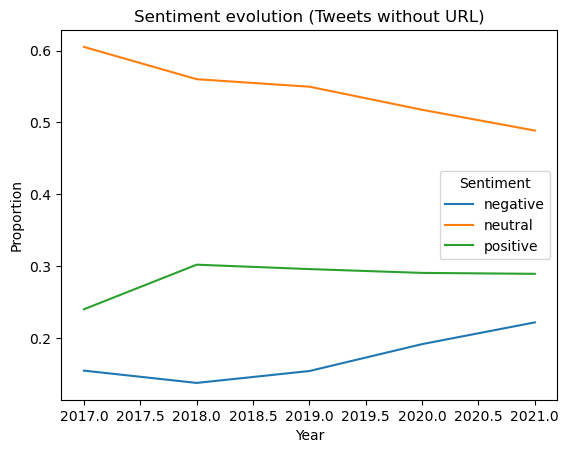

In [13]:
import matplotlib.pyplot as plt

# calcular proporciones
trend_no_url = (
    df_no_url
    .groupby("year")["sentiment_label_hf"]
    .value_counts(normalize=True)
    .unstack()
)

# gráfico
plt.figure()
trend_no_url.plot()
plt.title("Sentiment evolution (Tweets without URL)")
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.legend(title="Sentiment")
plt.show()

<Figure size 640x480 with 0 Axes>

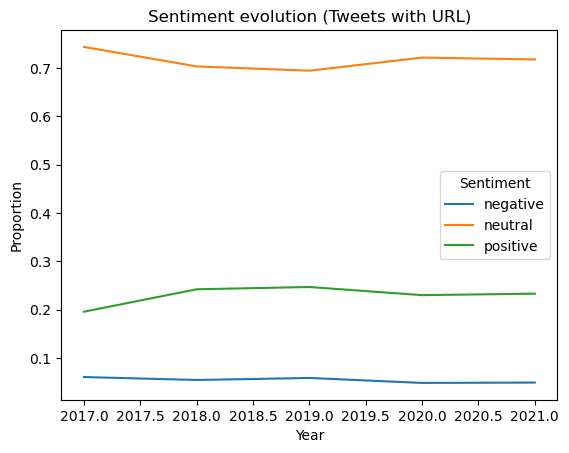

In [14]:
df_url = df[df["has_url"] == True]
# calcular proporciones
trend_url = (
    df_url
    .groupby("year")["sentiment_label_hf"]
    .value_counts(normalize=True)
    .unstack()
)

# gráfico
plt.figure()
trend_url.plot()
plt.title("Sentiment evolution (Tweets with URL)")
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.legend(title="Sentiment")
plt.show()

Al segmentar por presencia de enlaces, se observan dos dinámicas distintas. Los tweets que incluyen URLs (≈85% del total) presentan un tono predominantemente neutral y muy estable a lo largo del tiempo, lo que sugiere un comportamiento de difusión de contenido (noticias, artículos, recursos). En cambio, los tweets sin URL muestran una evolución hacia una mayor polarización: disminuye el peso del tono neutral y aumenta progresivamente la negatividad, especialmente a partir de 2019–2021.

## Análisis por sectores

In [15]:
sector_keywords = {

    "employment": [
        "job", "jobs", "employment", "employ", "worker", "workers",
        "workforce", "automation", "automate", "layoff", "layoffs",
        "salary", "career", "hiring", "unemployment",
        "replace", "replaced", "replacing", "labor", "labour",
        "reskill", "upskill"
    ],

    "healthcare": [
        "health", "healthcare", "hospital", "medical",
        "doctor", "physician", "patient", "patients",
        "diagnosis", "treatment", "clinical", "medicine",
        "pharma", "drug", "biotech", "radiology",
        "cardiology", "disease", "covid"
    ],

    "finance": [
        "bank", "banks", "banking", "finance", "financial",
        "fintech", "stock", "stocks", "investment", "investing",
        "trading", "market", "markets", "asset",
        "insurance", "credit", "risk", "fraud"
    ],

    "education": [
        "school", "schools", "education", "educational",
        "university", "college", "student", "students",
        "teacher", "teachers", "classroom",
        "learning", "curriculum", "edtech"
    ],

    "ethics": [
        "ethic", "ethics", "bias", "biased",
        "fairness", "discrimination", "privacy",
        "surveillance", "transparency", "accountability",
        "trust", "responsible", "explainable",
        "xai", "ai ethics"
    ],

    "regulation": [
        "regulation", "regulatory", "law", "legal",
        "policy", "policies", "government",
        "governance", "compliance", "gdpr",
        "eu", "european commission", "ai act",
        "legislation", "act", "framework"
    ],

    "technology": [
        "software", "hardware", "startup", "research",
        "innovation", "developer", "developers",
        "tool", "platform", "algorithm",
        "deep learning", "machine learning",
        "neural network", "ai model",
        "data science", "big data", "cloud"
    ]
}

In [16]:
import re

def assign_sector(text):
    text = text.lower()
    sector_counts = {}

    for sector, keywords in sector_keywords.items():
        pattern = r"\b(" + "|".join(map(re.escape, keywords)) + r")\b"
        matches = re.findall(pattern, text)
        if matches:
            sector_counts[sector] = len(matches)

    if not sector_counts:
        return "other"

    return max(sector_counts, key=sector_counts.get)

df["sector"] = df["tweet_clean_filt"].apply(assign_sector)

In [17]:
df["sector"].value_counts(normalize=True)

sector
other         0.719211
technology    0.061290
education     0.060205
employment    0.043794
finance       0.043369
healthcare    0.038263
regulation    0.017357
ethics        0.016510
Name: proportion, dtype: float64

In [18]:
df_no_url = df[df["has_url"] == False].copy()

In [19]:
df_no_url.groupby(["year","sector"])["sentiment_label_hf"]\
         .value_counts(normalize=True)\
         .unstack()

sentiment_label_hf  negative   neutral  positive
year sector                                     
2017 education      0.079365  0.654321  0.266314
     employment     0.253345  0.527208  0.219447
     ethics         0.241803  0.602459  0.155738
     finance        0.088745  0.602814  0.308442
     healthcare     0.055944  0.685315  0.258741
     other          0.161867  0.602078  0.236055
     regulation     0.142405  0.674051  0.183544
     technology     0.090971  0.634080  0.274949
2018 education      0.084718  0.529900  0.385382
     employment     0.206897  0.498084  0.295019
     ethics         0.187500  0.562500  0.250000
     finance        0.089286  0.515625  0.395089
     healthcare     0.072559  0.555409  0.372032
     other          0.148800  0.574591  0.276609
     regulation     0.160360  0.504505  0.335135
     technology     0.053961  0.504069  0.441970
2019 education      0.107112  0.524284  0.368604
     employment     0.272000  0.448571  0.279429
     ethics         0.199341  0.499176  0.301483
     finance        0.112179  0.507479  0.380342
     healthcare     0.072072  0.547748  0.380180
     other          0.160113  0.563955  0.275932
     regulation     0.186047  0.533223  0.280731
     technology     0.082004  0.529255  0.388741
2020 education      0.127432  0.564202  0.308366
     employment     0.261618  0.418244  0.320138
     ethics         0.292887  0.439331  0.267782
     finance        0.232955  0.491477  0.275568
     healthcare     0.123839  0.479876  0.396285
     other          0.207469  0.517616  0.274914
     regulation     0.196911  0.494208  0.308880
     technology     0.074886  0.579909  0.345205
2021 education      0.152505  0.483660  0.363834
     employment     0.262411  0.457447  0.280142
     ethics         0.333333  0.405405  0.261261
     finance        0.215311  0.449761  0.334928
     healthcare     0.189055  0.427861  0.383085
     other          0.233029  0.491591  0.275380
     regulation     0.254545  0.500000  0.245455
     technology     0.128821  0.543668  0.327511

In [20]:
df["sector"].value_counts(normalize=True)

sector
other         0.719211
technology    0.061290
education     0.060205
employment    0.043794
finance       0.043369
healthcare    0.038263
regulation    0.017357
ethics        0.016510
Name: proportion, dtype: float64

In [21]:
df_sectorial = df[df["sector"] != "other"]
df_sectorial["sector"].value_counts(normalize=True)

sector
technology    0.218279
education     0.214415
employment    0.155968
finance       0.154453
healthcare    0.136270
regulation    0.061816
ethics        0.058799
Name: proportion, dtype: float64

### Deep dive sentimiento SECTORIAL en tweets sin urls 

In [22]:
df_no_url = df[df["has_url"] == False]
df_no_url_sector = df_no_url[df_no_url["sector"] != "other"]

sector_trend = (
    df_no_url_sector
    .groupby(["year","sector"])["sentiment_label_hf"]
    .value_counts(normalize=True)
    .unstack()
)

sector_trend.head(15)

sentiment_label_hf  negative   neutral  positive
year sector                                     
2017 education      0.079365  0.654321  0.266314
     employment     0.253345  0.527208  0.219447
     ethics         0.241803  0.602459  0.155738
     finance        0.088745  0.602814  0.308442
     healthcare     0.055944  0.685315  0.258741
     regulation     0.142405  0.674051  0.183544
     technology     0.090971  0.634080  0.274949
2018 education      0.084718  0.529900  0.385382
     employment     0.206897  0.498084  0.295019
     ethics         0.187500  0.562500  0.250000
     finance        0.089286  0.515625  0.395089
     healthcare     0.072559  0.555409  0.372032
     regulation     0.160360  0.504505  0.335135
     technology     0.053961  0.504069  0.441970
2019 education      0.107112  0.524284  0.368604

#### Deep dive en parte NEGATIVA

In [23]:
sector_negative = sector_trend["negative"].unstack("sector")
sector_negative

sector,education,employment,ethics,finance,healthcare,regulation,technology
year,,,,,,,
2017,0.079365,0.253345,0.241803,0.088745,0.055944,0.142405,0.090971
2018,0.084718,0.206897,0.187500,0.089286,0.072559,0.160360,0.053961
2019,0.107112,0.272000,0.199341,0.112179,0.072072,0.186047,0.082004
2020,0.127432,0.261618,0.292887,0.232955,0.123839,0.196911,0.074886
2021,0.152505,0.262411,0.333333,0.215311,0.189055,0.254545,0.128821


In [24]:
sector_positive = sector_trend["positive"].unstack("sector")
sector_positive

sector,education,employment,ethics,finance,healthcare,regulation,technology
year,,,,,,,
2017,0.266314,0.219447,0.155738,0.308442,0.258741,0.183544,0.274949
2018,0.385382,0.295019,0.250000,0.395089,0.372032,0.335135,0.441970
2019,0.368604,0.279429,0.301483,0.380342,0.380180,0.280731,0.388741
2020,0.308366,0.320138,0.267782,0.275568,0.396285,0.308880,0.345205
2021,0.363834,0.280142,0.261261,0.334928,0.383085,0.245455,0.327511


Al analizar solo los tweets sin URL, se observa que la percepción directa sobre la IA se vuelve menos neutral con el tiempo. La negatividad aumenta de forma clara entre 2017 y 2021. Sin embargo, este aumento no es igual en todos los sectores.

- En empleo, la percepción negativa es alta desde el inicio y se mantiene estable, lo que indica una preocupación estructural por la automatización.

- En ética y regulación, la negatividad crece especialmente a partir de 2020, lo que sugiere un mayor debate social.

- En finanzas se observa un cambio fuerte, pasando de un tono mayoritariamente positivo a uno mucho más equilibrado y crítico.

- En cambio, tecnología y salud mantienen una percepción más positiva y estable.

En conjunto, los datos no muestran un rechazo generalizado a la IA, sino una creciente polarización en determinados ámbitos.

### Gráfico Negativo por sectores

<Figure size 640x480 with 0 Axes>

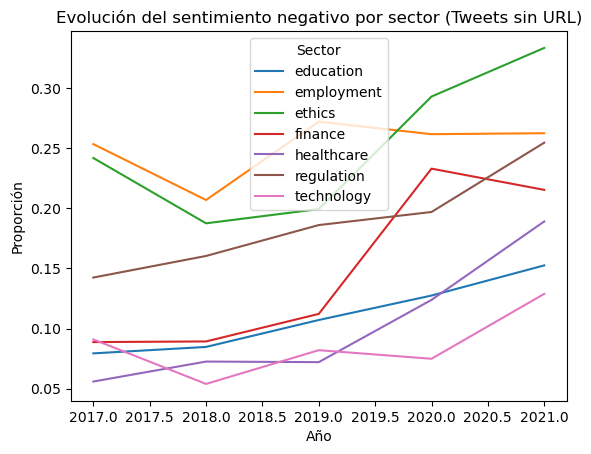

In [25]:
plt.figure()

sector_negative.plot()

plt.title("Evolución del sentimiento negativo por sector (Tweets sin URL)")
plt.xlabel("Año")
plt.ylabel("Proporción")
plt.legend(title="Sector")
plt.show()

### Gráfico Positivo por sectores

<Figure size 640x480 with 0 Axes>

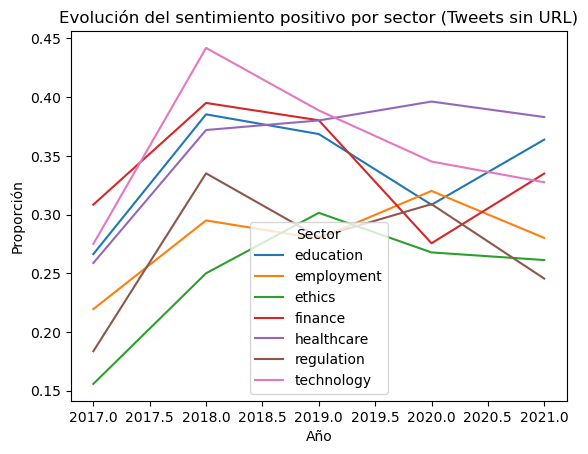

In [26]:
plt.figure()

sector_positive.plot()

plt.title("Evolución del sentimiento positivo por sector (Tweets sin URL)")
plt.xlabel("Año")
plt.ylabel("Proporción")
plt.legend(title="Sector")
plt.show()

In [27]:
tweets_por_ano = df.groupby("year").size()
tweets_por_ano

year
2017    299326
2018    212896
2019    201992
2020     76544
2021     29534
dtype: int64

In [28]:
df_no_url = df[df["has_url"] == False]
df_no_url.groupby("year").size()

year
2017    27585
2018    31621
2019    35124
2020    14134
2021     6765
dtype: int64

In [29]:
df_no_url_sector = df_no_url[df_no_url["sector"] != "other"]

df_no_url_sector.groupby(["year","sector"]).size().unstack()

sector,education,employment,ethics,finance,healthcare,regulation,technology
year,,,,,,,
2017,1134,1121,244,924,429,316,1473
2018,1806,1305,384,896,758,555,2335
2019,2306,1750,607,936,1110,602,2256
2020,1028,581,239,352,646,259,1095
2021,459,282,111,209,201,110,458


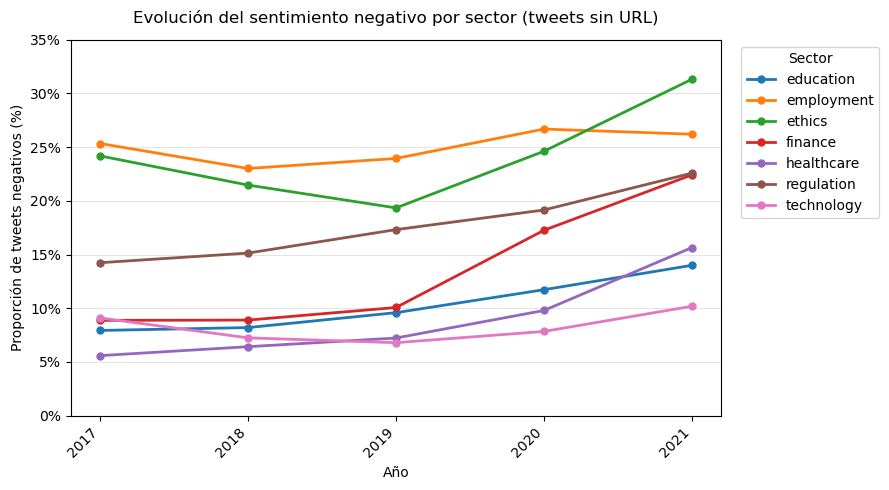

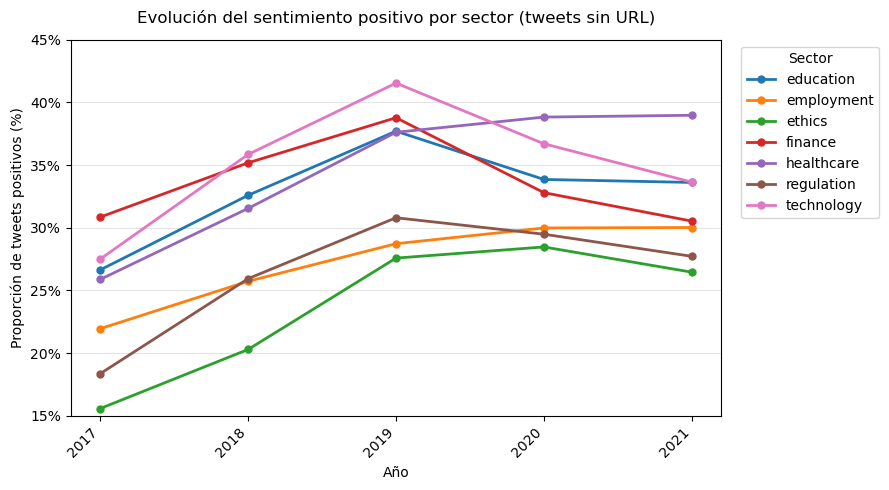

In [30]:
neg_smooth = sector_negative.rolling(2, min_periods=1).mean()
pos_smooth = sector_positive.rolling(2, min_periods=1).mean()

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_lines_with_markers(df_plot, title, ylabel, ylim=None):
    """
    df_plot: DataFrame con index = años (int) y columnas = sectores, valores = proporciones [0,1]
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    # Eje X como enteros (para evitar 2020.0)
    years = df_plot.index.astype(int)

    # Plot: una línea por sector + marcadores en cada año
    for col in df_plot.columns:
        ax.plot(
            years,
            df_plot[col].values,
            marker="o",
            linewidth=2,
            markersize=5,
            label=col
        )

    # Título y ejes (más “académico”)
    ax.set_title(title, pad=12)
    ax.set_xlabel("Año")
    ax.set_ylabel(ylabel)

    # Límites y formato
    if ylim is not None:
        ax.set_ylim(*ylim)

    # Ticks del eje X: enteros + rotación 45º
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha="right")

    # Eje Y en porcentaje (más interpretable que 0.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

    # Rejilla suave
    ax.grid(True, which="major", axis="y", linewidth=0.6, alpha=0.4)

    # Leyenda fuera (para que no tape)
    ax.legend(title="Sector", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

    fig.tight_layout()
    plt.show()


# NEGATIVO
plot_lines_with_markers(
    neg_smooth,
    title="Evolución del sentimiento negativo por sector (tweets sin URL)",
    ylabel="Proporción de tweets negativos (%)",
    ylim=(0, 0.35)
)
# POSITIVO
plot_lines_with_markers(
    pos_smooth,
    title="Evolución del sentimiento positivo por sector (tweets sin URL)",
    ylabel="Proporción de tweets positivos (%)",
    ylim=(0.15, 0.45)
)

In [31]:
import random

# Filtramos tweets sin URL, sectoriales y negativos
df_neg = df[
    (df["has_url"] == False) &
    (df["sector"] != "other") &
    (df["sentiment_label_hf"] == "negative")
]

# Lista de sectores
sectores = df_neg["sector"].unique()

for sector in sectores:
    print(f"\n==================== {sector.upper()} ====================\n")
    
    sample = df_neg[df_neg["sector"] == sector].sample(5, random_state=123)
    
    for tweet in sample["tweet_clean_filt"]:
        print("-", tweet)


==================== ETHICS ====================

- humans should only trust themselves when it comes to reading raw price action implementing fundementals into analysis fuck your artificial intelligence
- at describes real threat of as powerful interests tapping into surveillance society big data
- may be misleading much more than so don t trust it too much
- no trust no confidence
- the most dangerous thing that artificial intelligence does is force accountability where there was none

==================== EDUCATION ====================

- we keep being told that artificial intelligence and machine learning are about to revolutionise the world and yet twitter s auto correct remains completely hippyless
- another conspiracy restless artificial intelligence elon musk warned us about in school are maybe wanting to run for office how do we cope with this
- another conspiracy the determined artificial intelligence elon musk warned us about in the alternate dimension are possibly wanting 

### Visualización para tweets CON URL

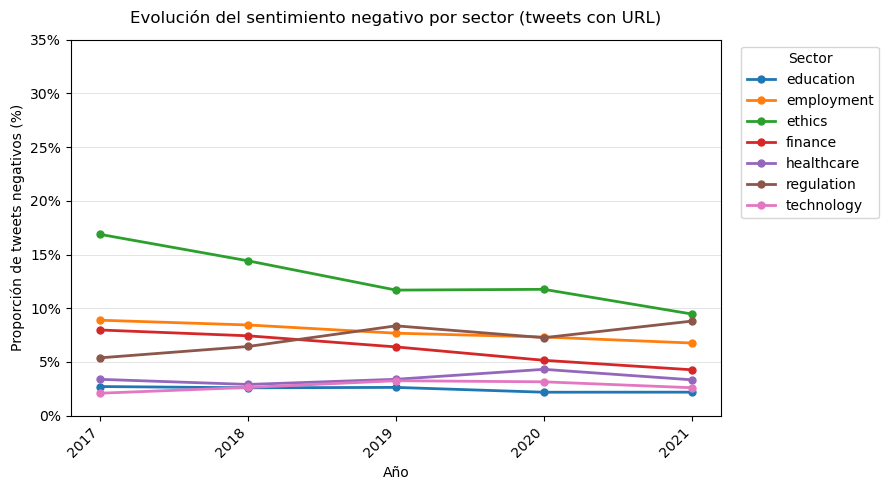

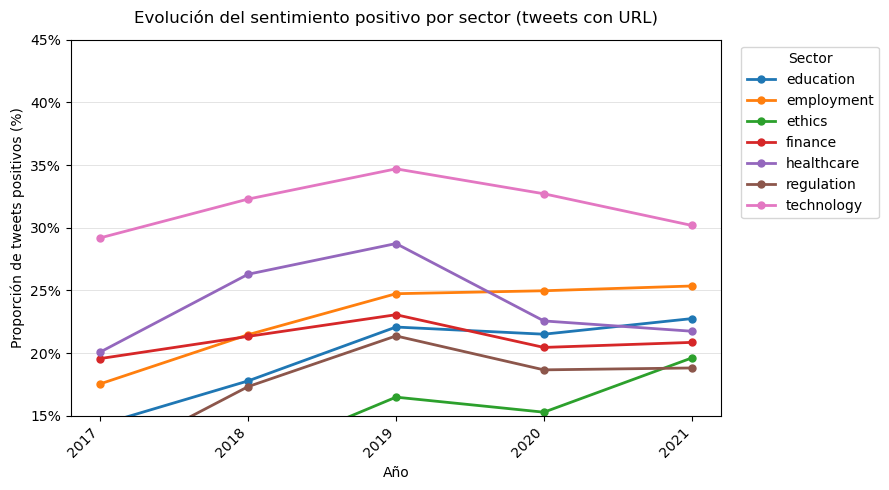

In [32]:
df_url = df[df["has_url"] == True].copy()
df_url_sector = df_url[df_url["sector"] != "other"].copy()

counts_url = (
    df_url_sector
    .groupby(["year", "sector", "sentiment_label_hf"])
    .size()
    .rename("n")
    .reset_index()
)

totals_url = (
    df_url_sector
    .groupby(["year", "sector"])
    .size()
    .rename("N")
    .reset_index()
)

counts_url = counts_url.merge(totals_url, on=["year", "sector"], how="left")
counts_url["prop"] = counts_url["n"] / counts_url["N"]

neg_url = counts_url[counts_url["sentiment_label_hf"] == "negative"] \
    .pivot(index="year", columns="sector", values="prop")

pos_url = counts_url[counts_url["sentiment_label_hf"] == "positive"] \
    .pivot(index="year", columns="sector", values="prop")

neg_url_smooth = neg_url.rolling(window=2, min_periods=1).mean()
pos_url_smooth = pos_url.rolling(window=2, min_periods=1).mean()

plot_lines_with_markers(
    neg_url_smooth,
    title="Evolución del sentimiento negativo por sector (tweets con URL)",
    ylabel="Proporción de tweets negativos (%)",
    ylim=(0, 0.35)
)

plot_lines_with_markers(
    pos_url_smooth,
    title="Evolución del sentimiento positivo por sector (tweets con URL)",
    ylabel="Proporción de tweets positivos (%)",
    ylim=(0.15, 0.45)
)

Al comparar ambos tipos de discurso, se observa una diferencia clara. En los tweets sin URL, la negatividad aumenta de forma más marcada en sectores como ética, regulación y finanzas, mostrando una mayor polarización con el paso del tiempo.

En cambio, en los tweets que incluyen enlaces, las tendencias son mucho más estables y la proporción de mensajes negativos se mantiene relativamente baja. Esto sugiere que el discurso espontáneo y personal sobre la IA tiende a ser más emocional y crítico, mientras que el contenido que comparte información externa presenta un tono más moderado y equilibrado.

# Deep dive de causas subyacentes por sectores

### Regulación europea y AI Act

In [40]:
# 1. Definimos keywords regulatorias
reg_keywords = [
    "regulation", "regulatory", "ai act", "governance",
    "law", "legal", "compliance", "eu", "european commission",
    "gdpr", "policy"
]

#2. Filtrar tweets que mencionan regulación
import re

pattern = "|".join(reg_keywords)

df_reg = df[df["tweet_clean_filt"].str.contains(pattern, case=False, na=False)]


In [41]:
df_reg["tweet"].sample(10, random_state=42)

466862                                                                                                                                                                                      London AI growth outpacing European rivals #ArtificialIntelligence   https://t.co/KSS8VjGnBw
784409                                                   How Artificial Intelligence Is Helping Fight The COVID-19 Pandemic - Entrepreneur  Read more here:  https://t.co/li9oKJGv8Z  #ArtificialIntelligence #AI #DataScience #MachineLearning #BigData #DeepLearning #NLP #Robots #IoT
732864                              https://t.co/9B8cMow4VO  Artificial Intelligence, the over/misuse of the tech buzzword and a look at whether it really is the job threat to paralegal jobs it's often portrayed to be.   #paralegal #law #legaltech #AI #automation #lawyer #lawfirm
223481                                                                                                                               #AI #DL #ML 4 Lesser-Kno

In [42]:
#3. Ver evolución temporal de menciones
df_reg.groupby("year").size()

year
2017    8904
2018    7964
2019    8243
2020    3608
2021    1428
dtype: int64

In [43]:
#4. Proporción sobre el total anual
reg_by_year = df_reg.groupby("year").size()
total_by_year = df.groupby("year").size()

(reg_by_year / total_by_year)

year
2017    0.029747
2018    0.037408
2019    0.040809
2020    0.047136
2021    0.048351
dtype: float64

In [44]:
# Sentimiento dentro de tweets regulatorios
df_reg.groupby("year")["sentiment_label_hf"].value_counts(normalize=True).unstack()

sentiment_label_hf,negative,neutral,positive
year,,,
2017,0.094901,0.769766,0.135332
2018,0.079106,0.674661,0.246233
2019,0.104816,0.683853,0.211331
2020,0.066519,0.737251,0.196231
2021,0.101541,0.672969,0.225490


In [46]:
df_reg_no_url = df_reg[df_reg["has_url"] == False]
df_reg_url = df_reg[df_reg["has_url"] == True]

df_reg_no_url.groupby("year")["sentiment_label_hf"]\
             .value_counts(normalize=True)\
             .unstack()

sentiment_label_hf,negative,neutral,positive
year,,,
2017,0.175141,0.612994,0.211864
2018,0.136707,0.519637,0.343656
2019,0.182523,0.543340,0.274137
2020,0.156061,0.501515,0.342424
2021,0.246094,0.527344,0.226562


In [47]:
df_reg_url.groupby("year")["sentiment_label_hf"]\
          .value_counts(normalize=True)\
          .unstack()

sentiment_label_hf,negative,neutral,positive
year,,,
2017,0.087970,0.783309,0.128721
2018,0.067620,0.705572,0.226807
2019,0.088658,0.713072,0.198271
2020,0.046472,0.790027,0.163501
2021,0.069966,0.704778,0.225256


In [57]:
import bertopic; print("bertopic OK", bertopic.__version__)
import sentence_transformers; print("sentence_transformers OK", sentence_transformers.__version__)
import umap; print("umap OK")
import hdbscan; print("hdbscan OK")

bertopic OK 0.17.4
sentence_transformers OK 5.2.3
umap OK
hdbscan OK


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import re, string, warnings
warnings.filterwarnings("ignore")

In [60]:
STOPWORDS = set([
    "i","me","my","we","our","you","your","he","she","they","them","his","her","their",
    "what","which","who","this","that","these","those","am","is","are","was","were",
    "be","been","being","have","has","had","do","does","did","get","got","let",
    "a","an","the","and","but","if","or","because","as","until","while","of","at",
    "by","for","with","about","between","into","through","during","before","after",
    "to","from","up","down","in","out","on","off","over","under","again","then",
    "once","here","there","when","where","why","how","all","any","both","each","few",
    "more","most","other","some","such","no","nor","not","only","own","same","so",
    "than","too","very","can","will","just","should","now","says","make","made",
    "may","also","would","could","use","used","using","one","new","need","like",
    "well","think","know","want","take","time","even","many","much","way","said",
    "say","see","look","come","going","put","set","keep","work","via","today",
    "rt","amp","tco","co","http","https","cc",
    "ai","artificialintelligence","artificial","intelligence","machinelearning",
    "machine","learning","deeplearning","deep","neural","network","networks",
    "model","models","data","bigdata","technology","tech","digital",
])

def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = text.replace("#", " ")
    text = text.translate(str.maketrans("", "", string.punctuation + "\u2019\u2018\u201c\u201d"))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) >= 4]
    return " ".join(tokens)

df_reg = df_reg.copy()
df_reg["tweet_clean"] = df_reg["tweet"].apply(clean_tweet)
df_reg = df_reg[df_reg["tweet_clean"].str.strip().str.len() > 10].reset_index(drop=True)

# Crea columna year si no existe — ajusta "date" al nombre real de tu columna de fecha
if "year" not in df_reg.columns:
    df_reg["year"] = pd.to_datetime(df_reg["date"], errors="coerce").dt.year

print(f"Tweets válidos en df_reg: {len(df_reg):,}")
print(df_reg["year"].value_counts().sort_index())

Tweets válidos en df_reg: 13,367
year
2017    4068
2018    3664
2019    3585
2020    1530
2021     520
Name: count, dtype: int64


In [61]:
N_PER_SENTIMENT = 5000
sentiments = ["negative", "neutral", "positive"]
frames = []

for sent in sentiments:
    subset = df_reg[df_reg["sentiment_label_hf"] == sent]
    n = min(N_PER_SENTIMENT, len(subset))
    
    if "year" in df_reg.columns:
        sampled = (subset
                   .groupby("year", group_keys=False)
                   .apply(lambda x: x.sample(
                       min(len(x), max(1, int(n * len(x) / len(subset)))),
                       random_state=42))
                  )
        if len(sampled) > n:
            sampled = sampled.sample(n, random_state=42)
    else:
        sampled = subset.sample(n, random_state=42)
    
    frames.append(sampled)

df_sample = pd.concat(frames).reset_index(drop=True)
print(f"Muestra total: {len(df_sample):,} tweets")
print(df_sample["sentiment_label_hf"].value_counts())
print(df_sample["year"].value_counts().sort_index())

Muestra total: 8,867 tweets
sentiment_label_hf
neutral     4998
positive    2666
negative    1203
Name: count, dtype: int64
year
2017    2540
2018    2530
2019    2426
2020    1009
2021     362
Name: count, dtype: int64


In [62]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Calculando embeddings... (~5-10 min en CPU)")
embeddings = model.encode(
    df_sample["tweet_clean"].tolist(),
    show_progress_bar=True,
    batch_size=64,
)
print(f"Embeddings calculados: {embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculando embeddings... (~5-10 min en CPU)


Batches:   0%|          | 0/139 [00:00<?, ?it/s]

Embeddings calculados: (8867, 384)


In [ ]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

vectorizer = CountVectorizer(
    stop_words=list(STOPWORDS),
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.85,
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    top_n_words=10,
    verbose=True,
)

topics, probs = topic_model.fit_transform(
    df_sample["tweet_clean"].tolist(),
    embeddings=embeddings,
)

df_sample["topic"] = topics

topic_info = topic_model.get_topic_info()
n_topics = topic_info[topic_info["Topic"] != -1]["Topic"].nunique()
n_outliers = (df_sample["topic"] == -1).sum()
print(f"\nTopics encontrados: {n_topics}")
print(f"Tweets sin topic (outliers): {n_outliers:,} ({100*n_outliers/len(df_sample):.1f}%)")
print("\n", topic_info.head(25).to_string())

2026-02-26 19:35:43,511 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


In [ ]:
print("\n═══ TOPICS ENCONTRADOS ═══\n")
for _, row in topic_model.get_topic_info().iterrows():
    if row["Topic"] == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(row["Topic"])]
    print(f"Topic {row['Topic']:>3} | {row['Count']:>5} tweets | {', '.join(words[:8])}")

In [ ]:
topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info["Topic"] != -1].copy()

# Mapea topic id → nombre legible
topic_name_map = topic_info.set_index("Topic")["Name"].to_dict()

df_plot = df_sample[df_sample["topic"] != -1].copy()
df_plot["topic_label"] = df_plot["topic"].map(topic_name_map)

# Distribución sentimiento por topic
sentiment_dist = (df_plot
    .groupby(["topic_label", "sentiment_label_hf"])
    .size()
    .unstack(fill_value=0))

# Añade columna total y filtra top 15 topics más grandes
sentiment_dist["total"] = sentiment_dist.sum(axis=1)
sentiment_dist = sentiment_dist.sort_values("total", ascending=False).head(15)

cols = [c for c in ["negative", "neutral", "positive"] if c in sentiment_dist.columns]
sentiment_pct = sentiment_dist[cols].div(sentiment_dist["total"], axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(13, 8))
colors = {"negative": "#d9534f", "neutral": "#5b9bd5", "positive": "#5cb85c"}
bottom = np.zeros(len(sentiment_pct))

for col in cols:
    vals = sentiment_pct[col].values
    bars = ax.barh(sentiment_pct.index, vals, left=bottom,
                   color=colors[col], label=col.capitalize(), height=0.6)
    # Etiqueta % dentro de la barra si hay espacio
    for bar, val in zip(bars, vals):
        if val > 8:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}%", ha="center", va="center",
                fontsize=8, color="white", fontweight="bold"
            )
    bottom += vals

ax.set_xlabel("% distribución de sentimiento", fontsize=11)
ax.set_title("Regulación IA · Distribución de sentimiento por topic",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="lower right", fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.invert_yaxis()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
df_time = df_sample[df_sample["topic"] != -1].copy()
df_time["topic_label"] = df_time["topic"].map(topic_name_map)

# Top 8 topics más frecuentes
top8 = (df_time.groupby("topic_label")
        .size()
        .sort_values(ascending=False)
        .head(8)
        .index.tolist())

df_time = df_time[df_time["topic_label"].isin(top8)]

pivot = (df_time
         .groupby(["year", "topic_label"])
         .size()
         .unstack(fill_value=0))

# Normaliza por año
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
cmap = plt.get_cmap("tab10")

for i, topic in enumerate(pivot_pct.columns):
    ax.plot(pivot_pct.index, pivot_pct[topic],
            marker="o", linewidth=2.5,
            label=topic, color=cmap(i))

ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("% de tweets del año", fontsize=11)
ax.set_title("Regulación IA · Evolución temporal de topics (2017-2021)",
             fontsize=13, fontweight="bold", pad=15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_xticks(pivot_pct.index)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()